# Adaptive Transfer Learning for Daily Physical Activity Monitoring

This notebook reproduces the core transfer learning framework and planned ablations/extensions from the paper:
*Daily Physical Activity Monitoring: Adaptive Learning from Multi-Source Motion Sensor Data*.

The framework consists of:
1. **Domain Similarity Computation:** IPD between target and source domains.
2. **Adaptive Pre-training:** Pre-train on source domains with similarity-weighted learning rates.
3. **Fine-tuning:** Fine-tune on the target domain.

We include the original paper experiment reproduction (binary classification task), followed by ablations on paired vs. unpaired similarity, adaptive vs. fixed learning rates, noise robustness, and an extension exploring different distance metrics (using multiclass classification).


In [1]:
!pip install pyts==0.13.0


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from pyts.metrics import dtw
from pyhealth.datasets import DSADataset, get_dataloader, split_by_patient, create_sample_dataset
from pyhealth.models.adaptive_transfer import AdaptiveTransferModel
from pyhealth.tasks import DSAActivityClassification
from pyhealth.trainer import Trainer
from pyhealth.metrics import multiclass_metrics_fn

# Configuration
SEED = 598
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
DSA_ROOT = "../HealthTimeSerial/data"
TARGET_UNIT = "LL"  # Target domain: Left Leg
ALL_UNITS = ("T", "RA", "LA", "RL", "LL")
SOURCE_UNITS = [u for u in ALL_UNITS if u != TARGET_UNIT]

BATCH_SIZE = 64
EPOCHS_PRETRAIN = 2
EPOCHS_FINETUNE = 4
BASE_LR = 1e-3

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": 0.3})


## 1. Data Loading
We load the dataset for each sensor unit and create aligned train/val/test splits to maintain the paired structure across domains.


In [3]:
base_dsa = DSADataset(root=DSA_ROOT, num_workers=1)

template_task = DSAActivityClassification(dataset_root=DSA_ROOT, selected_units=(ALL_UNITS[0],))
template_full = base_dsa.set_task(template_task, num_workers=1)
train_ref, val_ref, test_ref = split_by_patient(template_full, [0.5, 0.25, 0.25], seed=SEED)

patient_splits = {
    "train": set(train_ref.patient_to_index),
    "val": set(val_ref.patient_to_index),
    "test": set(test_ref.patient_to_index),
}

bundles = {}
for unit in ALL_UNITS:
    full = base_dsa.set_task(
        DSAActivityClassification(dataset_root=DSA_ROOT, selected_units=(unit,)),
        num_workers=1,
    )
    bundles[unit] = {
        "train": full.subset([idx for pid in patient_splits["train"] for idx in full.patient_to_index[pid]]),
        "val": full.subset([idx for pid in patient_splits["val"] for idx in full.patient_to_index[pid]]),
        "test": full.subset([idx for pid in patient_splits["test"] for idx in full.patient_to_index[pid]]),
    }


No config path provided, using default config
Initializing dsa dataset from ../HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/ead0c798-3b7d-5916-81ba-67f8e049d6c1
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/ead0c798-3b7d-5916-81ba-67f8e049d6c1/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/ead0c798-3b7d-5916-81ba-67f8e049d6c1/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/ead0c798-3b7d-5916-81ba-67f8e049d6c1/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task DSAActivityClassification for dsa base d

## 2. Core Framework Helper Functions
Define the DTW distance function, IPD computation, and a generic training routine.


In [4]:
def dtw_distance_fn(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    x_np, y_np = x.detach().cpu().numpy(), y.detach().cpu().numpy()
    if x_np.ndim == 1: x_np, y_np = x_np[None, :], y_np[None, :]
    vals = [dtw(np.ravel(a), np.ravel(b)) for a, b in zip(x_np, y_np)]
    return torch.tensor(vals, dtype=x.dtype, device=x.device)

def compute_mean_ipd(src_ds, tgt_ds, distance_fn=dtw_distance_fn, shuffle_target=False):
    model = AdaptiveTransferModel(
        dataset=bundles[TARGET_UNIT]["train"], feature_key="signal", backbone="lstm",
        distance_fn=distance_fn, use_kde_smoothing=True
    ).to(DEVICE)
    model.eval()
    
    src_loader = get_dataloader(src_ds, batch_size=BATCH_SIZE, shuffle=False)
    tgt_loader = get_dataloader(tgt_ds, batch_size=BATCH_SIZE, shuffle=shuffle_target)
    
    vals = [model.compute_ipd(s, t) for s, t in zip(src_loader, tgt_loader)]
    return float(np.mean(vals))

def train_and_evaluate(source_order, ipd_scores, data_bundles, use_adaptive_lr=True):
    model = AdaptiveTransferModel(
        dataset=data_bundles[TARGET_UNIT]["train"], feature_key="signal", backbone="lstm",
        use_similarity_weighting=use_adaptive_lr
    ).to(DEVICE)
    
    def train_step(train_ds, val_ds, epochs, lr):
        Trainer(model=model, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
            train_dataloader=get_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
            val_dataloader=get_dataloader(val_ds, batch_size=BATCH_SIZE, shuffle=False),
            epochs=epochs, optimizer_params={"lr": lr}, monitor="accuracy"
        )

    for src in source_order:
        lr = model.get_adaptive_lr(BASE_LR, 1.0 / (ipd_scores[src] + 1e-8)) if use_adaptive_lr else BASE_LR
        train_step(data_bundles[src]["train"], data_bundles[src]["val"], EPOCHS_PRETRAIN, lr)
        
    train_step(data_bundles[TARGET_UNIT]["train"], data_bundles[TARGET_UNIT]["val"], EPOCHS_FINETUNE, BASE_LR)
    
    trainer = Trainer(model=model, device=DEVICE, metrics=["accuracy"], enable_logging=False)
    return trainer.evaluate(get_dataloader(data_bundles[TARGET_UNIT]["test"], batch_size=BATCH_SIZE, shuffle=False))["accuracy"]


## 3. Original Paper Experiment Reproduction (Binary Task)
The original paper evaluates the framework on a binary classification task (one correct activity vs. rest) to calculate the Ratio of Correct Classification (RCC). We create a binary version of the dataset for this experiment (Activity 0 vs. Rest).

We compare three settings:
1. **No Transfer:** Training only on the target domain.
2. **Direct Transfer:** Sequential pre-training on source domains without similarity weighting, followed by fine-tuning.
3. **Adaptive IPD Transfer (Proposed):** Sequential pre-training ordered by IPD with similarity-weighted learning rates, followed by fine-tuning.


In [5]:
# Create binary datasets (Activity 0 vs Rest)
def make_binary_bundle(bundle, pos_class=0):
    bin_bundle = {}
    for split in ["train", "val", "test"]:
        samples = []
        for s in bundle[split]:
            s_new = dict(s)
            y = int(s["label"].item()) if hasattr(s["label"], "item") else int(s["label"])
            s_new["label"] = 1 if y == pos_class else 0
            samples.append(s_new)
        bin_bundle[split] = create_sample_dataset(samples, {"signal": "tensor"}, {"label": "binary"}, f"bin_{split}")
    return bin_bundle

binary_bundles = {unit: make_binary_bundle(bundles[unit], pos_class=0) for unit in ALL_UNITS}

# Compute Paired IPD for Adaptive Transfer (using binary validation sets)
paired_ipd_bin = {src: compute_mean_ipd(binary_bundles[src]["val"], binary_bundles[TARGET_UNIT]["val"], shuffle_target=False) for src in SOURCE_UNITS}
paired_order_bin = sorted(SOURCE_UNITS, key=paired_ipd_bin.get)

# 1. No Transfer
no_transfer_model_bin = AdaptiveTransferModel(dataset=binary_bundles[TARGET_UNIT]["train"], feature_key="signal", backbone="lstm").to(DEVICE)
Trainer(model=no_transfer_model_bin, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
    train_dataloader=get_dataloader(binary_bundles[TARGET_UNIT]["train"], batch_size=BATCH_SIZE, shuffle=True),
    val_dataloader=get_dataloader(binary_bundles[TARGET_UNIT]["val"], batch_size=BATCH_SIZE, shuffle=False),
    epochs=EPOCHS_PRETRAIN * len(SOURCE_UNITS) + EPOCHS_FINETUNE, optimizer_params={"lr": BASE_LR}, monitor="accuracy"
)
trainer_no_transfer_bin = Trainer(model=no_transfer_model_bin, device=DEVICE, metrics=["accuracy"], enable_logging=False)
acc_no_transfer_bin = trainer_no_transfer_bin.evaluate(get_dataloader(binary_bundles[TARGET_UNIT]["test"], batch_size=BATCH_SIZE, shuffle=False))["accuracy"]

# 2. Direct Transfer (Fixed LR, default order)
acc_direct_transfer_bin = train_and_evaluate(SOURCE_UNITS, paired_ipd_bin, binary_bundles, use_adaptive_lr=False)

# 3. Adaptive IPD Transfer (Proposed)
acc_adaptive_transfer_bin = train_and_evaluate(paired_order_bin, paired_ipd_bin, binary_bundles, use_adaptive_lr=True)


Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
Label label vocab: {0: 0, 1: 1}
AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x147b2bd50>
Monitor: accuracy
Monitor criterion: max
Epochs: 12
Patience: None



Epoch 0 / 12:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-0, step-143 ---
loss: 0.2493


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 136.03it/s]

--- Eval epoch-0, step-143 ---
accuracy: 0.9474
loss: 0.2044
New best accuracy score (0.9474) at epoch-0, step-143



...

Epoch 3 / 4:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-3, step-572 ---
loss: 0.2080


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 142.00it/s]

--- Eval epoch-3, step-572 ---
accuracy: 0.9474
loss: 0.1955
AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 143/143 [00:01<00:00, 137.26it/s]


/var/folders/_6/498k4xbs43l93lffcklb_r7m0000gn/T/ipykernel_75030/2754912406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["No Transfer", "Direct Transfer", "Adaptive IPD (Proposed)"],


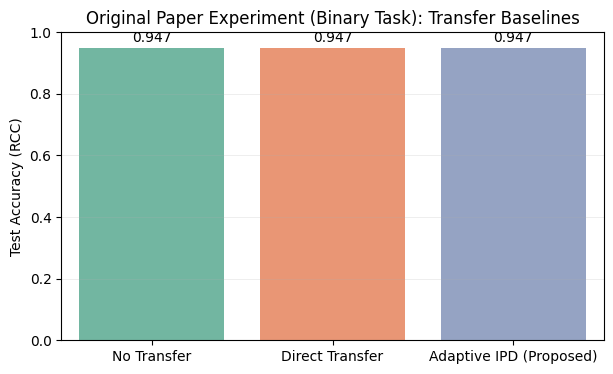

In [6]:
# Plotting Original Paper Experiment
plt.figure(figsize=(7, 4))
sns.barplot(x=["No Transfer", "Direct Transfer", "Adaptive IPD (Proposed)"], 
            y=[acc_no_transfer_bin, acc_direct_transfer_bin, acc_adaptive_transfer_bin], 
            palette="Set2")
plt.ylabel("Test Accuracy (RCC)")
plt.title("Original Paper Experiment (Binary Task): Transfer Baselines")
plt.ylim(0, 1.0)
for i, v in enumerate([acc_no_transfer_bin, acc_direct_transfer_bin, acc_adaptive_transfer_bin]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()


## 4. Ablation 1: Paired vs. Unpaired Similarity (H1)
*Note: For the following ablations and extensions, we use the **multiclass** classification task (all 19 activities) to provide a more challenging evaluation setting.*

We compare the IPD (which leverages synchronized, paired multi-sensor data) against an unpaired similarity measure (simulated by shuffling the target batch).


In [7]:
# Compute Paired IPD (Multiclass)
paired_ipd = {src: compute_mean_ipd(bundles[src]["val"], bundles[TARGET_UNIT]["val"], shuffle_target=False) for src in SOURCE_UNITS}
paired_order = sorted(SOURCE_UNITS, key=paired_ipd.get)

# Compute Unpaired IPD
unpaired_ipd = {src: compute_mean_ipd(bundles[src]["val"], bundles[TARGET_UNIT]["val"], shuffle_target=True) for src in SOURCE_UNITS}
unpaired_order = sorted(SOURCE_UNITS, key=unpaired_ipd.get)

acc_paired = train_and_evaluate(paired_order, paired_ipd, bundles, use_adaptive_lr=True)
acc_unpaired = train_and_evaluate(unpaired_order, unpaired_ipd, bundles, use_adaptive_lr=True)


AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.0028221019365477613}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x1088c2550>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-0, step-143 ---
loss: 2.8335


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 99.90it/s]

--- Eval epoch-0, step-143 ---
accuracy: 0.1444
loss: 2.7553
New best accuracy score (0.1444) at epoch-0, step-143



...

Epoch 3 / 4:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-3, step-572 ---
loss: 1.2650


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 102.09it/s]

--- Eval epoch-3, step-572 ---
accuracy: 0.5620
loss: 1.1769
New best accuracy score (0.5620) at epoch-3, step-572
AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 143/143 [00:01<00:00, 94.57it/s]


/var/folders/_6/498k4xbs43l93lffcklb_r7m0000gn/T/ipykernel_75030/1315026989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Paired IPD (Proposed)", "Unpaired Similarity"], y=[acc_paired, acc_unpaired], palette="viridis")


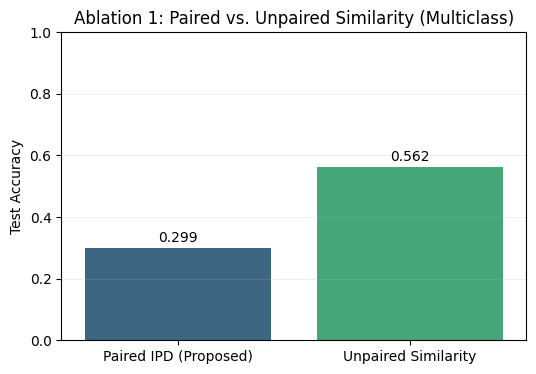

In [8]:
# Plotting Ablation 1
plt.figure(figsize=(6, 4))
sns.barplot(x=["Paired IPD (Proposed)", "Unpaired Similarity"], y=[acc_paired, acc_unpaired], palette="viridis")
plt.ylabel("Test Accuracy")
plt.title("Ablation 1: Paired vs. Unpaired Similarity (Multiclass)")
plt.ylim(0, 1.0)
for i, v in enumerate([acc_paired, acc_unpaired]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()


## 5. Ablation 2: Adaptive LR vs. Fixed LR (H2)
We evaluate the impact of similarity-weighted learning-rate adaptation by training with a fixed learning-rate schedule across source domains (using the IPD ranked order).


In [9]:
acc_fixed_lr_ipd_order = train_and_evaluate(paired_order, paired_ipd, bundles, use_adaptive_lr=False)


AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x141a3d050>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-0, step-143 ---
loss: 2.7512


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 113.80it/s]

--- Eval epoch-0, step-143 ---
accuracy: 0.1393
loss: 2.5845
New best accuracy score (0.1393) at epoch-0, step-143



...

Epoch 3 / 4:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-3, step-572 ---
loss: 2.2620


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 93.42it/s] 

--- Eval epoch-3, step-572 ---
accuracy: 0.3239
loss: 2.0472
New best accuracy score (0.3239) at epoch-3, step-572
AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 143/143 [00:01<00:00, 110.22it/s]


/var/folders/_6/498k4xbs43l93lffcklb_r7m0000gn/T/ipykernel_75030/3165176271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Adaptive LR (Proposed)", "Fixed LR"], y=[acc_paired, acc_fixed_lr_ipd_order], palette="magma")


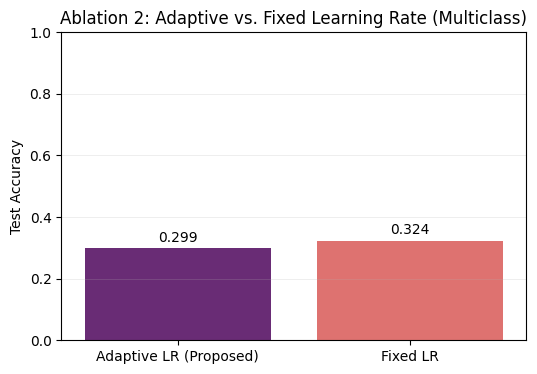

In [10]:
# Plotting Ablation 2
plt.figure(figsize=(6, 4))
sns.barplot(x=["Adaptive LR (Proposed)", "Fixed LR"], y=[acc_paired, acc_fixed_lr_ipd_order], palette="magma")
plt.ylabel("Test Accuracy")
plt.title("Ablation 2: Adaptive vs. Fixed Learning Rate (Multiclass)")
plt.ylim(0, 1.0)
for i, v in enumerate([acc_paired, acc_fixed_lr_ipd_order]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()


## 6. Ablation 3: Robustness to Noise (H3)
We replicate the noise injection experiment using Gaussian perturbations to verify the robustness benefits of the transfer learning framework.


In [11]:
def evaluate_with_noise(model, test_ds, noise_stds):
    model.eval()
    test_loader = get_dataloader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    results = []
    
    for std in noise_stds:
        ys, ps = [], []
        for data in test_loader:
            data = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v) for k, v in data.items()}
            if std > 0:
                data["signal"] = data["signal"] + torch.randn_like(data["signal"]) * std
            with torch.no_grad():
                out = model(**data)
            ys.append(out["y_true"].cpu().numpy())
            ps.append(out["y_prob"].cpu().numpy())
        acc = multiclass_metrics_fn(np.concatenate(ys), np.concatenate(ps), metrics=["accuracy"])["accuracy"]
        results.append(acc)
    return results

# Train a No-Transfer baseline for comparison
no_transfer_model = AdaptiveTransferModel(dataset=bundles[TARGET_UNIT]["train"], feature_key="signal", backbone="lstm").to(DEVICE)
Trainer(model=no_transfer_model, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
    train_dataloader=get_dataloader(bundles[TARGET_UNIT]["train"], batch_size=BATCH_SIZE, shuffle=True),
    val_dataloader=get_dataloader(bundles[TARGET_UNIT]["val"], batch_size=BATCH_SIZE, shuffle=False),
    epochs=EPOCHS_PRETRAIN * len(SOURCE_UNITS) + EPOCHS_FINETUNE, optimizer_params={"lr": BASE_LR}, monitor="accuracy"
)

# Re-train adaptive model to evaluate
adaptive_model = AdaptiveTransferModel(dataset=bundles[TARGET_UNIT]["train"], feature_key="signal", backbone="lstm", use_similarity_weighting=True).to(DEVICE)
for src in paired_order:
    Trainer(model=adaptive_model, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
        train_dataloader=get_dataloader(bundles[src]["train"], batch_size=BATCH_SIZE, shuffle=True),
        val_dataloader=get_dataloader(bundles[src]["val"], batch_size=BATCH_SIZE, shuffle=False),
        epochs=EPOCHS_PRETRAIN, optimizer_params={"lr": adaptive_model.get_adaptive_lr(BASE_LR, 1.0 / (paired_ipd[src] + 1e-8))}, monitor="accuracy"
    )
Trainer(model=adaptive_model, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
    train_dataloader=get_dataloader(bundles[TARGET_UNIT]["train"], batch_size=BATCH_SIZE, shuffle=True),
    val_dataloader=get_dataloader(bundles[TARGET_UNIT]["val"], batch_size=BATCH_SIZE, shuffle=False),
    epochs=EPOCHS_FINETUNE, optimizer_params={"lr": BASE_LR}, monitor="accuracy"
)

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3]
acc_noise_no_transfer = evaluate_with_noise(no_transfer_model, bundles[TARGET_UNIT]["test"], noise_levels)
acc_noise_adaptive = evaluate_with_noise(adaptive_model, bundles[TARGET_UNIT]["test"], noise_levels)


AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x15d842350>
Monitor: accuracy
Monitor criterion: max
Epochs: 12
Patience: None



Epoch 0 / 12:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-0, step-143 ---
loss: 2.7374


Evaluation: 100%|██████████| 143/143 [00:00<00:00, 143.08it/s]

--- Eval epoch-0, step-143 ---
accuracy: 0.1833
loss: 2.4654
New best accuracy score (0.1833) at epoch-0, step-143



...

--- Eval epoch-2, step-429 ---
accuracy: 0.5669
loss: 1.2044
New best accuracy score (0.5669) at epoch-2, step-429



Epoch 3 / 4:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-3, step-572 ---
loss: 1.2704


Evaluation: 100%|██████████| 143/143 [00:02<00:00, 66.07it/s] 


--- Eval epoch-3, step-572 ---
accuracy: 0.5834
loss: 1.1461
New best accuracy score (0.5834) at epoch-3, step-572


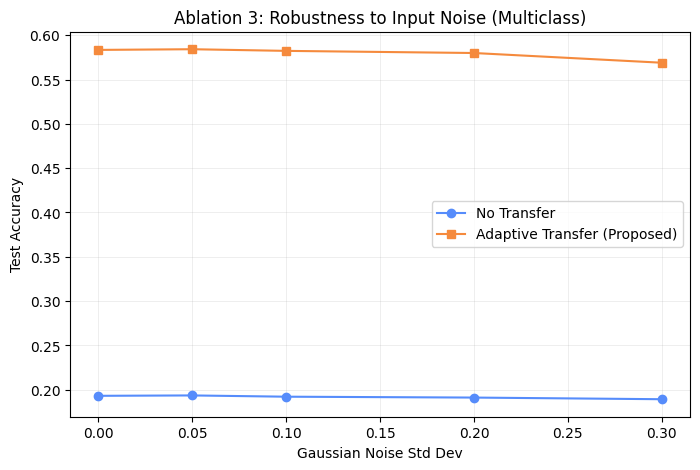

In [12]:
# Plotting Ablation 3
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, acc_noise_no_transfer, marker='o', label="No Transfer")
plt.plot(noise_levels, acc_noise_adaptive, marker='s', label="Adaptive Transfer (Proposed)")
plt.xlabel("Gaussian Noise Std Dev")
plt.ylabel("Test Accuracy")
plt.title("Ablation 3: Robustness to Input Noise (Multiclass)")
plt.legend()
plt.show()


## 7. Extension: Distance Metrics Comparison
We evaluate various distance methods within IPD: Euclidean, Minkowski (p=3), and DTW.


In [13]:
distance_metrics = {
    "DTW": dtw_distance_fn,
    "Euclidean": "euclidean",
    "Minkowski (p=3)": lambda x, y: F.pairwise_distance(x, y, p=3)
}

metric_results = {}
ipd_heatmap_data = np.zeros((len(distance_metrics), len(SOURCE_UNITS)))

for i, (name, dist_fn) in enumerate(distance_metrics.items()):
    ipd_vals = {src: compute_mean_ipd(bundles[src]["val"], bundles[TARGET_UNIT]["val"], distance_fn=dist_fn) for src in SOURCE_UNITS}
    order = sorted(SOURCE_UNITS, key=ipd_vals.get)
    acc = train_and_evaluate(order, ipd_vals, bundles, use_adaptive_lr=True)
    metric_results[name] = acc
    
    for j, src in enumerate(SOURCE_UNITS):
        ipd_heatmap_data[i, j] = ipd_vals[src]


AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.0027063629381163727}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x146e7d950>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-0, step-143 ---
loss: 2.8236


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 103.60it/s]

--- Eval epoch-0, step-143 ---
accuracy: 0.1419
loss: 2.7425
New best accuracy score (0.1419) at epoch-0, step-143



...

Epoch 3 / 4:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-3, step-572 ---
loss: 1.0866


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 92.71it/s]

--- Eval epoch-3, step-572 ---
accuracy: 0.6143
loss: 1.0012
New best accuracy score (0.6143) at epoch-3, step-572
AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 143/143 [00:01<00:00, 112.87it/s]


/var/folders/_6/498k4xbs43l93lffcklb_r7m0000gn/T/ipykernel_75030/81864927.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metric_results.keys()), y=list(metric_results.values()), palette="coolwarm")


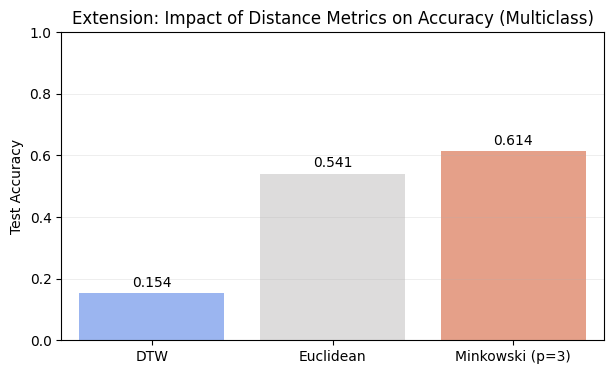

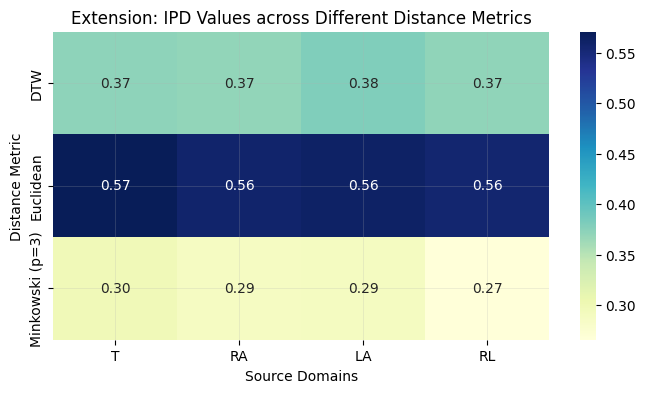

In [14]:
# Plotting Extension Results
# 1. Bar Chart for Accuracy Comparison
plt.figure(figsize=(7, 4))
sns.barplot(x=list(metric_results.keys()), y=list(metric_results.values()), palette="coolwarm")
plt.ylabel("Test Accuracy")
plt.title("Extension: Impact of Distance Metrics on Accuracy (Multiclass)")
plt.ylim(0, 1.0)
for i, v in enumerate(metric_results.values()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()

# 2. Heatmap for IPD Values across Metrics
plt.figure(figsize=(8, 4))
sns.heatmap(ipd_heatmap_data, annot=True, fmt=".2f", xticklabels=SOURCE_UNITS, yticklabels=list(distance_metrics.keys()), cmap="YlGnBu")
plt.xlabel("Source Domains")
plt.ylabel("Distance Metric")
plt.title("Extension: IPD Values across Different Distance Metrics")
plt.show()
